In [1]:
import os
import base64
from typing import TypedDict, List, Optional
from PIL import Image
from IPython.display import display as ipy_display
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# 1. define state
class AgentState(TypedDict):
    text: str
    image_path: str
    options: List[str]     
    prediction: str         
    confidence: float       
    final_label: str       

# 2. Define AI Prediction Node
def multimodal_predict_node(state: AgentState):
    print("\n--- [Node: AI Predict] 正在进行多模态分析 ---")
    # Simulating a low-confidence scenario
    return {
        "prediction": "Harmful", 
        "confidence": 0.45  
    }

# 3. Define Human Labeling Node (Manual Intervention)
def human_label_node(state: AgentState):

    print("\n--- [Node: Human In The Loop] Triggering Manual Intervention ---")
    
    # Display text
    print(f"Text to classify: {state['text']}")
    
    # Display Image in Jupyter/VS Code
    try:
        img = Image.open(state['image_path'])
        ipy_display(img)
    except Exception as e:
        print(f"Image display error: {e}")

    # Dynamic options prompt based on user input
    options_hint = "/".join(state['options'])
    user_input = input(f"AI uncertain (Conf: {state['confidence']}). Enter label ({options_hint}): ")
    
    return {"final_label": user_input}

# 4. Define Routing Logic (Conditional Edge)
def should_ask_human(state: AgentState):
    if state["confidence"] < 0.6:
        return "human_label_node"  
    return END  

In [3]:
# 5. Build Graph Architecture
builder = StateGraph(AgentState)

builder.add_node("multimodal_predict_node", multimodal_predict_node)
builder.add_node("human_label_node", human_label_node)

builder.add_edge(START, "multimodal_predict_node")

# Key: Conditional routing based on confidence score
builder.add_conditional_edges(
    "multimodal_predict_node",
    should_ask_human,
)

builder.add_edge("human_label_node", END)

# 6. [Core] Add Checkpointer and Interrupt Mechanism
memory = MemorySaver()
# Compile graph with persistence and manual intervention breakpoint
app = builder.compile(
    checkpointer=memory, 
    interrupt_before=["human_label_node"] 
)

In [4]:
config = {"configurable": {"thread_id": "simone_session_001"}}

initial_input = {
    "text": "When you can't decide to pre heat the oven, or just throw the meal in right away.",
    "image_path": "test_image.jpg",
    "options": ["Harmful", "Neutral", "Positive"]
}

print("--- Starting Agent ---")
# Initial run
for event in app.stream(initial_input, config): #type: ignore
    print(event)

--- Starting Agent ---

--- [Node: AI Predict] 正在进行多模态分析 ---
{'multimodal_predict_node': {'prediction': 'Harmful', 'confidence': 0.45}}
{'__interrupt__': ()}



--- Resuming from Breakpoint ---

--- [Node: Human In The Loop] Triggering Manual Intervention ---
Text to classify: When you can't decide to pre heat the oven, or just throw the meal in right away.


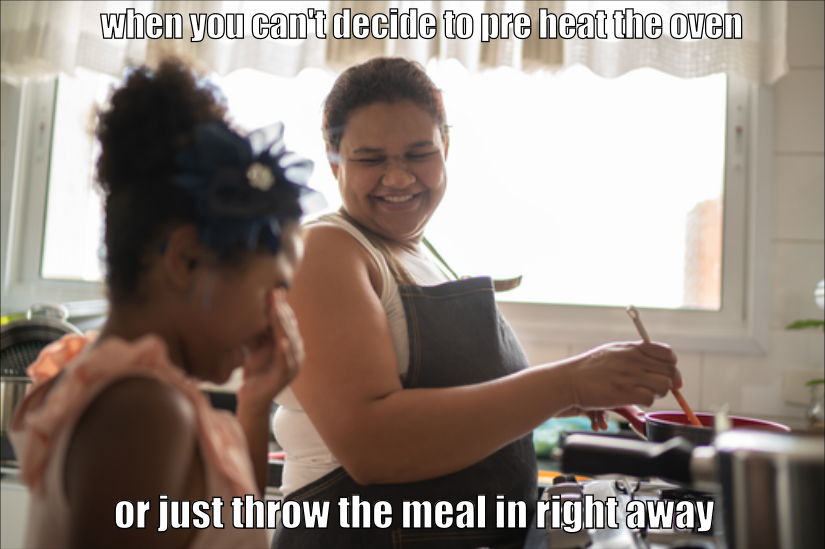

{'text': "When you can't decide to pre heat the oven, or just throw the meal in right away.",
 'image_path': 'test_image.jpg',
 'options': ['Harmful', 'Neutral', 'Positive'],
 'prediction': 'Harmful',
 'confidence': 0.45,
 'final_label': 'Neutral'}

In [5]:
# Resume execution: Enter the human_label_node to get input and finish
print("\n--- Resuming from Breakpoint ---")
app.invoke(None, config) #type:ignore